In [1]:
import numpy as np
from numpy.random import default_rng
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pymc3 as pm
import arviz as az
import torch
import torch.distributions as D

from insilico_stimuli.stimuli import GaborSet

seed = 42
rng = default_rng(seed=seed)
torch.manual_seed(seed=seed)
EPSILON = 1e-12
mpl.style.use("seaborn")
az.style.use("arviz-darkgrid")


In [2]:
z_dim = 18
Lambda = torch.ones(z_dim)
sigma = torch.abs(torch.rand(1)) + EPSILON

In [3]:
gabor_data = torch.load("/src/project/computed/gabors.pt")

In [4]:
gabor_data

{'gabors': <insilico_stimuli.stimuli.GaborSet at 0x7f62445ce5b0>,
 'params': {'canvas_size': [50, 50],
  'sizes': [15],
  'spatial_frequencies': [0.05],
  'contrasts': [1.0],
  'grey_levels': [0.0],
  'eccentricities': [0.0],
  'locations': [(10, 10),
   (10, 25),
   (10, 40),
   (25, 10),
   (25, 25),
   (25, 40),
   (40, 10),
   (40, 25),
   (40, 40)],
  'orientations': [3.141592653589793, 1.5707963267948966],
  'phases': [1.5707963267948966],
  'relative_sf': False}}

In [5]:
gabors = gabor_data["gabors"].images()

In [6]:
gabors.shape

(18, 50, 50)

In [7]:
gabors = torch.tensor(gabors).float()

In [8]:
(gabors.permute(1, 2, 0) @ D.Exponential(Lambda).sample()).shape

torch.Size([50, 50])

In [9]:
gabors.shape

torch.Size([18, 50, 50])

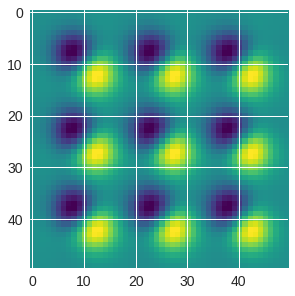

In [10]:
plt.imshow(gabors.sum(dim=0))

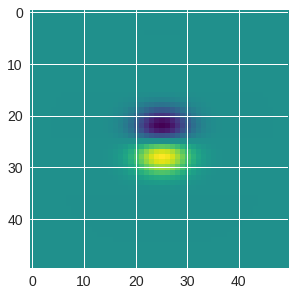

In [11]:
plt.imshow(gabors[9])

In [12]:
stimulus = gabors[9]

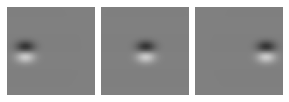

In [13]:
gabor_params = {
    "canvas_size"         : [50, 50],
    "sizes"               : [15],
    "spatial_frequencies" : [1/20],
    "contrasts"           : [1.0],
    "grey_levels"         : [0.0],
    "eccentricities"      : [0.0],
    "locations"           : [[10, 25], [25, 25], [40, 25]],
    "orientations"        : [np.pi/2],  
    "phases"              : [np.pi/2],
    "relative_sf"         : False
}

gabor_set = GaborSet(**gabor_params)
                     
plt.figure(figsize=(10, 5))
for i, img in enumerate(gabor_set.images()):
    plt.subplot(4, 8, i + 1)
    plt.imshow(img, cmap='gray', vmin=-1, vmax=1)
    plt.axis('off')

In [14]:
stimuli = torch.tensor(gabor_set.images()).float().sum(dim=0)

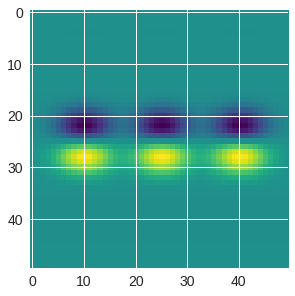

In [22]:
plt.imshow(stimuli)

In [23]:
model = pm.Model()
with model:
    z = pm.Exponential("neuron", lam=Lambda, shape=z_dim)
    x = pm.Normal("stimulus", mu=(gabors.permute(1, 2, 0) @ z), sigma=sigma, observed=stimuli)
    trace = pm.sample(1_000, return_inferencedata=False)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [neuron]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 32 seconds.


In [24]:
trace["neuron"].shape

(4000, 18)

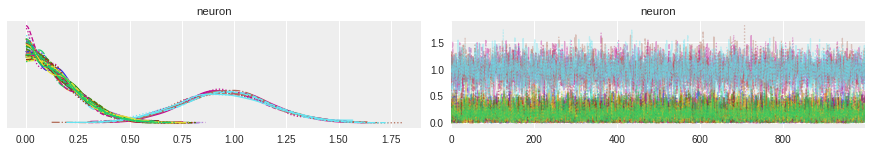

In [25]:
with model:
    az.plot_trace(trace)

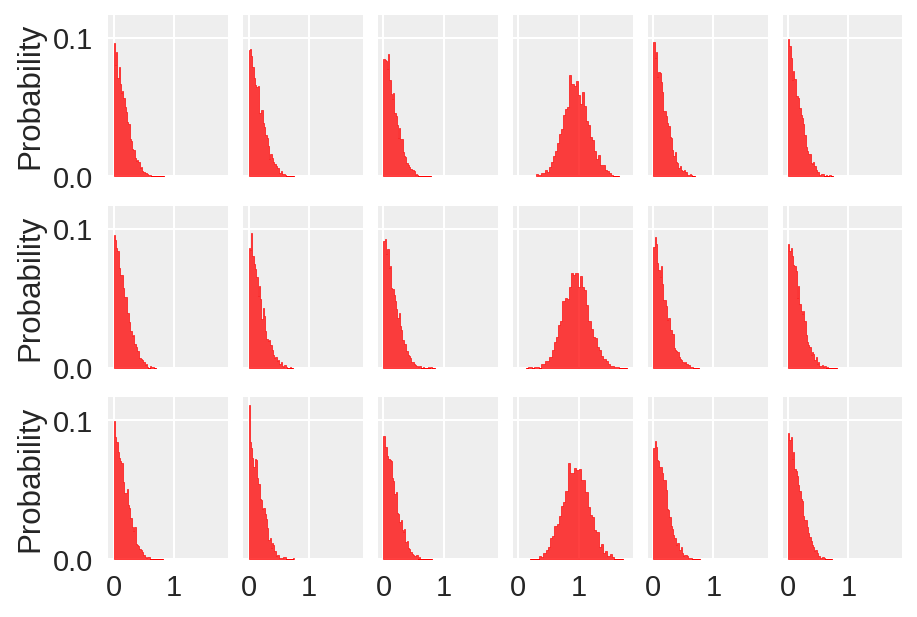

In [26]:
fig, axs = plt.subplots(nrows=3, ncols=6, dpi=150, sharex=True, sharey=True)
for idx, ax in enumerate(axs.ravel()):
    sns.histplot(trace["neuron"][:, idx].ravel(), color="red", stat="probability", element="step", ax=ax)
    # ax.imshow(gabors[idx], cmap="gray")


In [27]:
trace["neuron"].shape

(4000, 18)

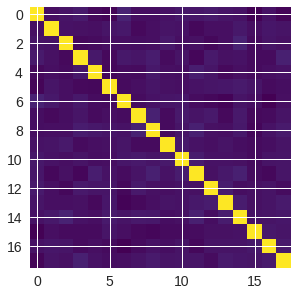

In [28]:
plt.imshow(np.corrcoef(trace["neuron"].T))